In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.spatial import KDTree
import scipy.signal as signal
%matplotlib inline

In [19]:
# Load data

data = loadmat('sampleEEGdata.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'EEG'])

In [20]:
# Extract Data And Initialize Variables

eeg = data['EEG']
eeg_data = eeg['data'][0, 0]
sampling_rate = eeg['srate'][0, 0][0, 0]
time_vector = eeg['times'][0, 0]
channels = 64
timepoints = len(time_vector[0])
trials = 99
nyquist = int (sampling_rate / 2)

eeg_data.shape, sampling_rate, time_vector.shape, timepoints

((64, 640, 99), np.uint16(256), (1, 640), 640)

In [21]:
# Create An FIR Filter For Each Frequency In The Specified Frequency Range

total_frequencies = 30
frequency_range = [5, 90]
frequencies = np.linspace(frequency_range[0], frequency_range[1], total_frequencies)

width = 1.5
order = int(4 * sampling_rate / frequency_range[0])

filters = np.zeros((total_frequencies, order))

for i in range(total_frequencies):
  filter_range = np.array([frequencies[i] - width, frequencies[i] + width]) / nyquist

  filters[i, :] = signal.firwin(order, filter_range, pass_zero = 'bandpass')

In [33]:
# Index Of Frequency Of Interest

frequency = np.array([[5]])

kdt = KDTree(frequencies.reshape(total_frequencies, 1))
_, idx = kdt.query(frequency)

frequencies[idx[0]]

array([5.])

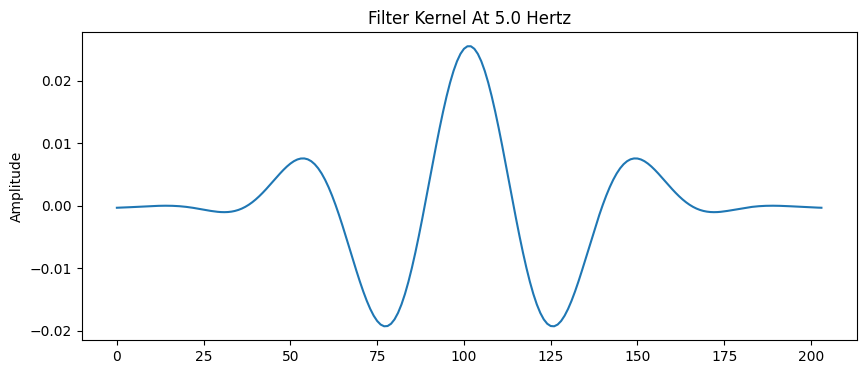

In [46]:
# Visualize A Filter Kernel In The Time Domain

plt.close('all')
plt.figure(figsize=(10, 4))
plt.plot(filters[idx[0]])
plt.title(f'Filter Kernel At {frequencies[idx[0]]} Hertz')
plt.ylabel('Amplitude')
plt.show()

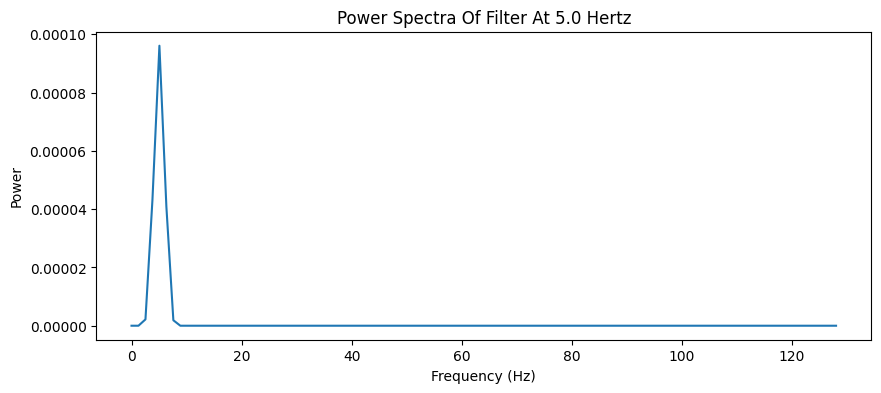

In [45]:
# Visualize A Filter In The Frequency Domain

power = (2 * np.abs(np.fft.fft(filters[idx]) / order)) ** 2
frequency_vector = np.linspace(0, nyquist, int(order / 2))

plt.close('all')
plt.figure(figsize=(10, 4))
plt.plot(frequency_vector, power[0, :len(frequency_vector)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title(f'Power Spectra Of Filter At {np.round(frequencies[idx[0]])} Hertz')
plt.show()

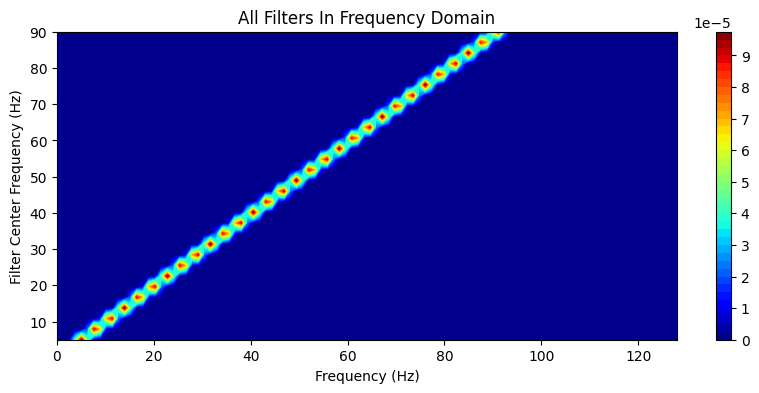

In [25]:
# Visualize All Filters In the Frequency Domain

filter_spectra_all= np.zeros((total_frequencies, len(frequency_vector)))

for i in range(total_frequencies):
  power = (2 * np.abs(np.fft.fft(filters[i]) / order)) ** 2
  filter_spectra_all[i, :] = power[:len(frequency_vector)]

plt.close('all')
plt.figure(figsize=(10, 4))
plt.contourf(frequency_vector, frequencies, filter_spectra_all, 42, cmap='jet')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Filter Center Frequency (Hz)')
plt.title('All Filters In Frequency Domain')
plt.colorbar()
plt.show()

In [28]:
# Extract Time-Frequency Power via The Filter-Hilbert Method

time_freq_power = np.zeros((channels, total_frequencies, timepoints))

for i in range(total_frequencies):
  for j in range(channels):
    # Reshape Signal Into 1 Dimension
    sig = np.reshape(eeg_data[j], (-1), order='F')

    # Filter Signal
    sig_filt = signal.filtfilt(filters[i], 1, sig)

    # Pass Filtered Signal To Hilbert Function
    sig_hilb = signal.hilbert(sig_filt)

    # Reshape Signal Back To Original Dimension
    sig_hilb = np.reshape(sig_hilb, (timepoints, trials), order='F')

    # Extract Power
    time_freq_power[j, i, :] = np.mean((np.abs(sig_hilb) ** 2), axis=1)

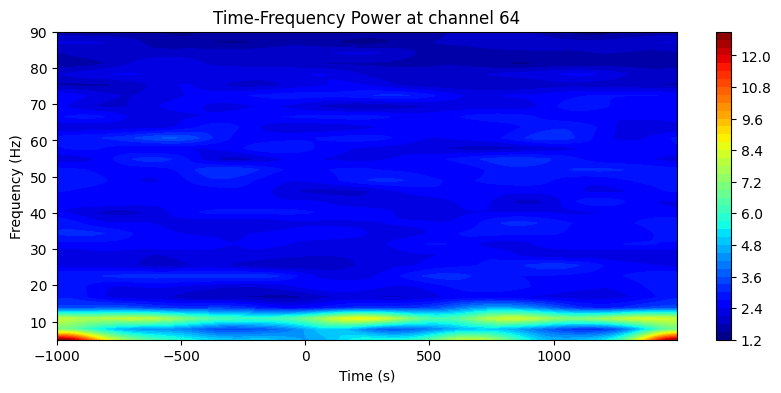

In [39]:
# Visualize Time-Frequncy Power Of A Channel Of Interest

channel = 63

plt.close('all')
plt.figure(figsize=(10, 4))
plt.contourf(time_vector[0], frequencies, time_freq_power[channel], 42, cmap='jet')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title(f'Time-Frequency Power at channel {channel+1}')
plt.colorbar()
plt.show()